In [ ]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#dataset load krwane mai help karegi
from datasets import load_dataset

Load the dair-ai/emotion dataset from Hugging Face. https://huggingface.co/datasets/dair-ai/emotion

In [ ]:
emotion_dataset=load_dataset("dair-ai/emotion")

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
# import pickle
# import numpy as np
# from google.colab import drive
# from tensorflow.keras.models import load_model
# from tensorflow.keras.preprocessing.sequence import pad_sequences

# # 1. Mount Google Drive
# drive.mount('/content/drive')

# # 2. Load the saved fitted Tokenizer
# with open('/content/drive/MyDrive/tokenizer.pkl', 'rb') as f:
#     tokenizer = pickle.load(f)

# # 3. Load your trained Keras models from Drive
# rnn_model  = load_model('/content/drive/MyDrive/model_rnn.keras')
# lstm_model = load_model('/content/drive/MyDrive/model_lstm.keras')
# gru_model  = load_model('/content/drive/MyDrive/model_gru.keras')
# BiGRU      = load_model('/content/drive/MyDrive/model_bigru.keras')

# print("Tokenizer and all 4 models loaded successfully into memory!")

In [ ]:
train_text=emotion_dataset['train']['text']
train_label=emotion_dataset['train']['label']

test_text=emotion_dataset['test']['text']
test_label=emotion_dataset['test']['label']

In [ ]:
label_names=emotion_dataset['train'].features['label'].names

In [ ]:
df_train=pd.DataFrame(
    {
        'text': train_text,
      'label':[label_names[i] for i in train_label]
     }
)

df_test=pd.DataFrame(
    {
        'text': test_text,
      'label':[label_names[i] for i in test_label]
     }
)

In [ ]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


In [ ]:
df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='object', name='label')

<Axes: xlabel='label', ylabel='count'>

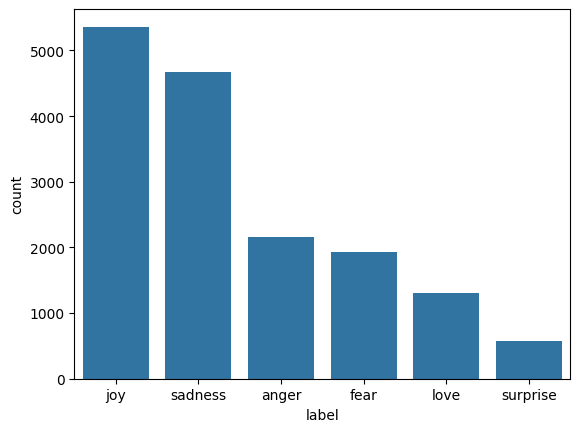

In [ ]:
sns.countplot(x='label',data=df_train,order=df_train['label'].value_counts().index)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words=10000
tokenizer=Tokenizer(num_words=max_words,oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence=tokenizer.texts_to_sequences(df_train['text'])
test_sequence=tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence=pad_sequences(train_sequence,maxlen=50,padding='post',truncating='post')
padded_test_sequence=pad_sequences(test_sequence,maxlen=50,padding='post',truncating='post')

train_labels=np.array(train_label)
test_labels=np.array(test_label)

num_classes=len(np.unique(train_labels))

print(f"vocabulary size: {len(tokenizer.word_index)}")
print(f"max senetnce length: {padded_train_sequence.shape[1]}")


vocabulary size: 15213
max senetnce length: 50


In [ ]:
from sklearn.utils import class_weight

class_weights=class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weight_dict=dict(enumerate(class_weights))

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping=EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense,Dropout,LSTM,GRU,SimpleRNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:

# rnn_model.fit(
#     padded_train_sequence,
#     train_labels,
#     validation_data=(padded_test_sequence, test_labels),
#     epochs = 20,
#     batch_size=32,
#     class_weight=class_weight_dict,
#     callbacks=[early_stopping]
# )

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.1760 - loss: 1.8034
RNN Loss: 1.8033912181854248
RNN Accuracy: 0.17599999904632568


In [ ]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

# lstm_model.fit(
#     padded_train_sequence,
#     train_labels,
#     validation_data=(padded_test_sequence, test_labels),
#     epochs = 20,
#     batch_size=32,
#     class_weight=class_weight_dict,
#     callbacks=[early_stopping]
# )

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.0820 - loss: 1.7896
LSTM Loss: 1.7895902395248413
LSTM Accuracy: 0.0820000022649765


In [ ]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

# gru_model.fit(
#     padded_train_sequence,
#     train_labels,
#     validation_data=(padded_test_sequence, test_labels),
#     epochs = 20,
#     batch_size=32,
#     class_weight=class_weight_dict,
#     callbacks=[early_stopping]
# )

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.3455 - loss: 1.7896
GRU Loss: 1.789612889289856
GRU Accuracy: 0.34549999237060547


In [ ]:

result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
    }).sort_values(by='Test Accuracy',ascending=False)
result_df


,Model,Test Loss,Test Accuracy
2,GRU,1.789613,0.3455
0,RNN,1.803391,0.1760
1,LSTM,1.789590,0.0820


In [ ]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') #Output Layer
    #Why i used num_classes in output layer and what will i get from this.
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [ ]:

BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 168s 322ms/step - accuracy: 0.5851 - loss: 1.0387 - val_accuracy: 0.8725 - val_loss: 0.4156
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 199s 317ms/step - accuracy: 0.9144 - loss: 0.2523 - val_accuracy: 0.9115 - val_loss: 0.2578
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 161s 322ms/step - accuracy: 0.9429 - loss: 0.1580 - val_accuracy: 0.9220 - val_loss: 0.2195
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 160s 320ms/step - accuracy: 0.9594 - loss: 0.1093 - val_accuracy: 0.9190 - val_loss: 0.2543
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 160s 319ms/step - accuracy: 0.9695 - loss: 0.0865 - val_accuracy: 0.9145 - val_loss: 0.2944
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 159s 318ms/step - accuracy: 0.9754 - loss: 0.0669 - val_accuracy: 0.9185 - val_loss: 0.2541


In [ ]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")


63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.9220 - loss: 0.2195
BiGRU Loss: 0.219492569565773
BiGRU Accuracy: 0.921999990940094


In [ ]:
# from google.colab import drive
# import pickle

# # 1. Mount Google Drive
# drive.mount('/content/drive')

# # 2. Save Keras Models to Drive
# rnn_model.save('/content/drive/MyDrive/model_rnn.keras')
# lstm_model.save('/content/drive/MyDrive/model_lstm.keras')
# gru_model.save('/content/drive/MyDrive/model_gru.keras')
# BiGRU.save('/content/drive/MyDrive/model_bigru.keras')

# # 3. Save the fitted Tokenizer (CRITICAL for FastAPI deployment later!)
# with open('/content/drive/MyDrive/tokenizer.pkl', 'wb') as f:
#     pickle.dump(tokenizer, f)

# print("All models and tokenizer successfully saved to Google Drive!")

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step


<Axes: >

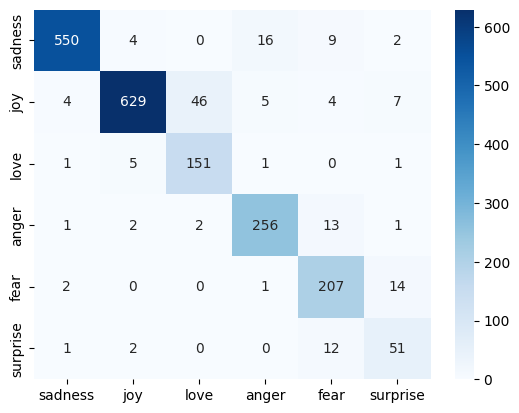

In [ ]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)

In [ ]:
sample_texts = [
    "I love you dear",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
Text: I love you dear
Predicted Emotion: anger
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


In [ ]:

import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) #yeh folder hai jiske andar sari exported file aane wali hai

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Modle.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)


In [ ]:
label_names[0]

'sadness'